========== 3.1 Missing Values Summary ==========
                Missing Values  Missing %
Churn Reason              5174      73.46
Churn Category            5174      73.46
Offer                     3877      55.05
Internet Type             1526      21.67




C:\Users\jonnn\AppData\Local\Temp\ipykernel_24696\1189982987.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


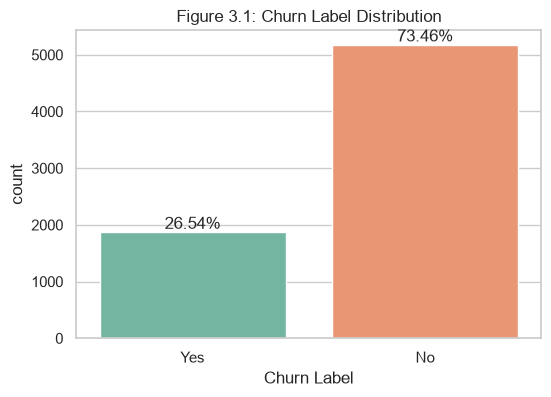

========== 3.3 VIF Multicollinearity Analysis ==========
            Feature  VIF Score
0  Tenure in Months   6.400530
1    Monthly Charge   3.222244
2     Total Charges  24.395622
3     Total Revenue  21.314548




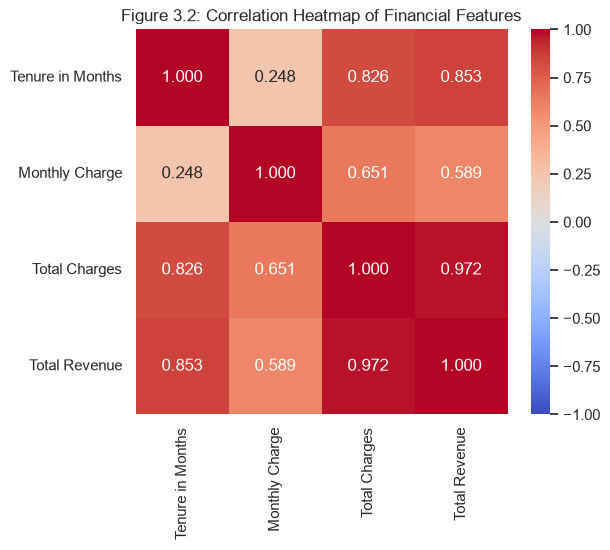

========== 3.4 Skewness Summary ==========
                             Skewness
Total Refunds                    4.33
Total Extra Data Charges         4.09
Total Long Distance Charges      1.24
Avg Monthly GB Download          1.22
Total Revenue                    0.92




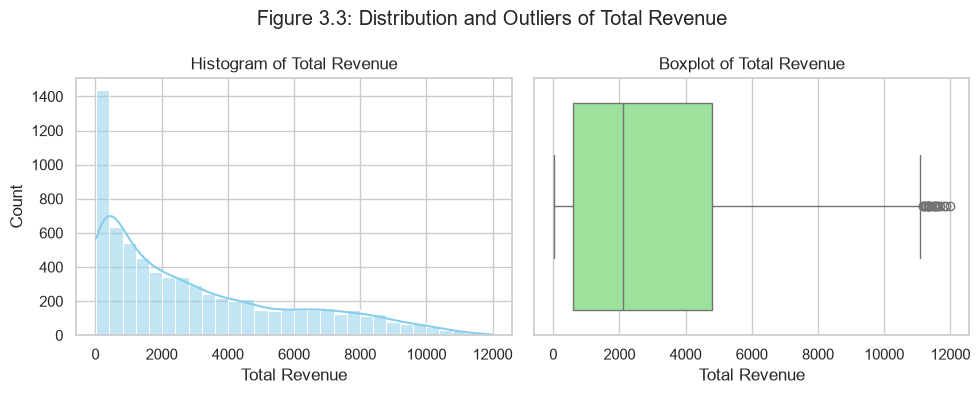

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset and set the chart style
df = pd.read_csv('telco.csv')
sns.set_theme(style="whitegrid")

print("========== 3.1 Missing Values Summary ==========")

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing[missing['Missing Values'] > 0].sort_values(
    by='Missing %',
    ascending=False
))

print("\n")


# ========== 3.2 Class Imbalance ==========
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x='Churn Label',
    palette='Set2'
)

plt.title('Figure 3.1: Churn Label Distribution')

# Add percentages above each bar for clearer evidence
total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    ax.annotate(
        percentage,
        (x, y),
        ha='center',
        va='bottom'
    )

plt.show()


print("========== 3.3 VIF Multicollinearity Analysis ==========")

# Select strongly related financial features for VIF calculation
vif_cols = [
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Revenue'
]

vif_data = df[vif_cols].dropna()

vif_df = pd.DataFrame()

vif_df["Feature"] = vif_cols

vif_df["VIF Score"] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(len(vif_cols))
]

print(vif_df)

print("\n")


# Create a correlation heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    vif_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    vmin=-1,
    vmax=1
)

plt.title('Figure 3.2: Correlation Heatmap of Financial Features')

plt.show()


print("========== 3.4 Skewness Summary ==========")

# Select the highly skewed features identified previously
skew_cols = [
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Avg Monthly GB Download'
]

skew_df = pd.DataFrame({
    'Skewness': df[skew_cols].skew().round(2)
})

print(
    skew_df.sort_values(
        by='Skewness',
        ascending=False
    )
)

print("\n")


# ========== 3.4 Skewness and Outliers ==========
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(
    df['Total Revenue'],
    bins=30,
    kde=True,
    ax=axes[0],
    color='skyblue'
)

axes[0].set_title('Histogram of Total Revenue')


sns.boxplot(
    x=df['Total Revenue'],
    ax=axes[1],
    color='lightgreen'
)

axes[1].set_title('Boxplot of Total Revenue')

plt.suptitle(
    'Figure 3.3: Distribution and Outliers of Total Revenue'
)

plt.tight_layout()

plt.show()
